Welcome to Voxelmap!

The first thing we'll do is train the neural network (Network A). We'll then test the network to see how it performs.

# Imports


## Imports and Setup

This cell initializes the core libraries required for the experiment.

- Standard Python utilities for timing, file system access, and numerical computation
- PyTorch for deep learning, optimization, and dataset handling
- Matplotlib for visualization
- Project-specific modules for network definitions and loss functions
- Warning suppression to keep notebook output clean

These imports form the foundation for model training, evaluation, and result analysis in subsequent cells.


In [1]:

# imports
import time
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
from utilities import losses
import torch
from torch.utils.data import Dataset
import torch.optim as optim
import warnings
import random

warnings.filterwarnings("ignore")

joint_work_dir = os.path.join(os.getcwd(), "joint_work")
if joint_work_dir not in sys.path:
    sys.path.append(joint_work_dir)

from networks2 import SingleEncoderDualDecoder



# File Names

## Experiment Configuration

This cell defines the experiment metadata and dataset configuration.

- Specifies patient identifier, treatment day, and dataset type
- Selects scatter or no-scatter data (Scatter is added in Treatment day 2 Dataset)
- Constructs the input image directory based on the chosen configuration
- Defines experiment description and output filename for logging and checkpoints

This configuration block ensures consistency and reproducibility across training runs.


In [2]:
random.seed(42)

In [4]:

import os

Patient_number = "P2"
NoScatter = True
Scatter = False
DatasetType = "SPARE"
DayofTreatment = 1
NetworkType = "SED2_balanced_lamda"
UseSkipConnections = True
ModeTag = "supervised"
lambda_image = 1  # auxiliary image-loss weight

if NoScatter == Scatter:
    raise ValueError("Set exactly one of NoScatter or Scatter to True.")

scatter_tag = "NS" if NoScatter else "SC"

im_dir = os.path.join(
    "/srv/shared/SPARE",  # update to your data root
    f"MC_V_{Patient_number}_{scatter_tag}_{DayofTreatment:02d}"
)

ArchitectureTag = "SPARE_SED2_balanced_lamda"
skip_tag = "skip" if UseSkipConnections else "noskip"
run_name = f"{ArchitectureTag}_{skip_tag}_{ModeTag}_lambda{lambda_image}_{Patient_number}"
filename = run_name
expt_description = f"{run_name} (Day {DayofTreatment} {'NoScatter' if NoScatter else 'Scatter'})"

print("im_dir =", im_dir)
print("run_name =", run_name)



im_dir = /srv/shared/SPARE/MC_V_P2_NS_01
run_name = SPARE_SED2_balanced_lamda_skip_supervised_lambda1_P2


# Setup Dataset

## Supervised Dataset Definition

This cell defines a custom PyTorch `Dataset` for supervised training.

- Loads source and target projections, volumes, and deformation vector fields (DVFs) from disk
- Applies min–max normalization to projection and volume data
- Constructs source–target pairs based on filename conventions
- Reshapes data into channel-first tensors compatible with PyTorch models
- Returns a dictionary containing all inputs and ground truth required for training

This dataset class standardizes data access and preprocessing for the training pipeline.


In [5]:
# set up training dataset class
class SupervisedDataset(Dataset):
    def __init__(self, im_dir=None, im_size=None):
        self.im_dir = im_dir
        self.im_size = im_size

    def __len__(self):
        return len([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy')])

    def __getitem__(self, idx):
        # Find target projection
        proj_list = sorted([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy')])
        target_file = proj_list[idx]
        proj_name = os.path.join(self.im_dir, format(target_file))
        target_proj = np.load(proj_name)
        target_proj = (target_proj - np.min(target_proj)) / (np.max(target_proj) - np.min(target_proj))

        # Find target DVF
        vol_num = target_file[:2]
        dvf_name = os.path.join(self.im_dir, format('DVF_' + vol_num + '_mha.npy'))
        target_dvf = np.load(dvf_name)

        # Find source projection
        source_file = '06_' + target_file[3:]
        proj_name = os.path.join(self.im_dir, format(source_file))
        source_proj = np.load(proj_name)
        source_proj = (source_proj - np.min(source_proj)) / (np.max(source_proj) - np.min(source_proj))

        # Find source volume
        vol_name = os.path.join(self.im_dir, format('subCT_06_mha.npy'))
        source_vol = np.load(vol_name)
        source_vol = (source_vol - np.min(source_vol)) / (np.max(source_vol) - np.min(source_vol))

        # Find source abdomen
        vol_name = os.path.join(self.im_dir, format('sub_Abdomen_mha.npy'))
        source_hull = np.load(vol_name)

        # Reshape data
        source_projections = np.zeros((1, self.im_size, self.im_size), dtype=np.float32)
        source_projections[0, :, :] = np.asarray(source_proj)
        target_projections = np.zeros((1, self.im_size, self.im_size), dtype=np.float32)
        target_projections[0, :, :] = np.asarray(target_proj)

        source_volumes = np.zeros((1, self.im_size, self.im_size, self.im_size), dtype=np.float32)
        source_volumes[0, :, :, :] = np.asarray(source_vol)
        source_abdomen = np.zeros((1, self.im_size, self.im_size, self.im_size), dtype=np.float32)
        source_abdomen[0, :, :, :] = np.asarray(source_hull)

        target_flow = np.zeros((3, self.im_size, self.im_size, self.im_size), dtype=np.float32)
        target_flow[0, :, :, :] = target_dvf[:, :, :, 0]
        target_flow[1, :, :, :] = target_dvf[:, :, :, 1]
        target_flow[2, :, :, :] = target_dvf[:, :, :, 2]

        data = {'source_projections': torch.from_numpy(source_projections),
                'target_projections': torch.from_numpy(target_projections),
                'source_volumes': torch.from_numpy(source_volumes),
                'source_abdomen': torch.from_numpy(source_abdomen),
                'target_flow': torch.from_numpy(target_flow)}

        return data

Lookin' good! Now we will create training and validation datasets

## Data Loading and Visualization

This cell creates a test data loader and retrieves a single example from the dataset.

- Initializes the dataset and `DataLoader` with batch size 1
- Extracts source projections, target projections, volumes, abdomen mask, and DVF
- Visualizes:
  - The source projection
  - A central axial slice from the source volume
  - A mid-slice component of the target deformation vector field (DVF)

This step provides a quick sanity check to verify data integrity, orientation, and alignment before training.


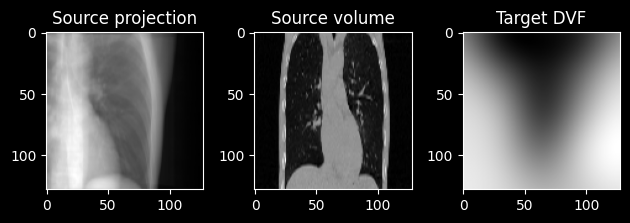

In [5]:
# Generate test loader
batch_size = 1
im_size = 128
exampleset = SupervisedDataset(im_dir=im_dir, im_size=im_size)
exampleloader = torch.utils.data.DataLoader(exampleset, batch_size=batch_size)
data = next(iter(exampleloader))

source_proj, target_proj, source_vol, source_abdomen, target_flow = data['source_projections'], \
                                                                                        data['target_projections'], \
                                                                                        data['source_volumes'], \
                                                                                        data['source_abdomen'], \
                                                                                        data['target_flow']
# visualise projection, volume and DVF
f = plt.figure()
plt.subplot(1,3,1)
source_proj = np.squeeze(source_proj)
plt.imshow(source_proj, cmap='gray')
plt.title('Source projection')

plt.subplot(1,3,2)
source_vol = np.squeeze(source_vol)
plt.imshow(np.transpose(source_vol[:,:, int(source_vol.shape[2] / 2)]), cmap='gray')
plt.title('Source volume')

plt.subplot(1,3,3)
target_flow = np.squeeze(target_flow)
plt.imshow(np.flipud(np.transpose(target_flow[1,:,:, int(source_vol.shape[2] / 2)])), cmap='gray')
plt.title('Target DVF')

f.tight_layout()
plt.show()

Network time! Let's set up a cuda implementation of the network, a loss function (good ol' MSE will do! but we're computing it within a thoracoabdominal mask) and an optimizer

In [6]:
import numpy as np

def get_numpy_similarity(path1, path2):
    # 1. Load the numpy arrays
    arr1 = np.load(path1)
    arr2 = np.load(path2)

    # 2. Flatten the arrays to 1D vectors
    # This works regardless of shape (e.g., 128x128x128 or 3x128x128x128)
    vec1 = arr1.flatten()
    vec2 = arr2.flatten()

    # 3. Calculate Dot Product
    dot_product = np.dot(vec1, vec2)

    # 4. Calculate Norms (Magnitudes)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    # 5. Compute Cosine Similarity
    # We add a tiny epsilon (1e-9) to avoid division by zero
    similarity = dot_product / (norm1 * norm2 + 1e-9)

    return similarity

# Usage
file_a = im_dir + "/06_Proj_00064_bin.npy"
file_b = "/srv/shared/SPARE/MC_V_P2_SC_02/"+ "source/06_Proj_00064_bin.npy"
score = get_numpy_similarity(file_a, file_b)
print(f"Cosine Similarity: {score:.6f}")

Cosine Similarity: 0.995928


It's important to note that , this difference is because there could have been changes to the anatomy between planning and treatment day.

# Training

## Training Setup

This cell prepares the data split, model, and optimization components for training.

- Splits the dataset into training and validation sets using a 90/10 ratio
- Creates shuffled data loaders for efficient batch processing
- Initializes the network architecture with the specified image size and integration steps
- Configures the computation device for GPU or CPU execution
- Defines the flow-based loss function and Adam optimizer with a fixed learning rate

This setup establishes all core elements required to begin model training.

In [6]:
# generate train/test split
im_size = 128
batch_size = 8
dataset = SupervisedDataset(im_dir=im_dir, im_size=im_size)
split = [int(len(dataset) * 0.9), int(len(dataset) * 0.1)]
trainset, valset = torch.utils.data.dataset.random_split(dataset, split)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=True)

In [7]:

import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from continue_training import (
    save_checkpoint,
    load_checkpoint_if_available,
    plot_losses,
)
from utilities import spatialTransform
from utilities import losses

# ---- device  ----
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# ---- set up network  ----
model = SingleEncoderDualDecoder(
    im_size=im_size,
    int_steps=10,
    skip_connections=UseSkipConnections,
).to(device)

# ---- losses + optimizer ----
flow_mask = losses.flow_mask()
image_loss_fn = losses.image_l1()
gt_transformer = spatialTransform.Network([im_size, im_size, im_size]).to(device).eval()
image_grad_fn = losses.image_grad()
lambda_grad = 0.2

lr = 1e-5
optimizer = optim.Adam(model.parameters(), lr=lr)

outputs_root = os.path.join("outputs", run_name)
save_dir = os.path.join(outputs_root, "weights")
plot_dir = os.path.join(outputs_root, "plots")
os.makedirs(save_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

ckpt_path = os.path.join(save_dir, f"{run_name}_ckpt.pth")
best_path = os.path.join(save_dir, f"{run_name}_best.pth")



In [12]:
def norm_z(x, eps=1e-6):
    mu = x.mean(dim=(2,3,4), keepdim=True)
    sd = x.std(dim=(2,3,4), keepdim=True)
    return (x - mu) / (sd + eps)


In [ ]:
# =========================
# TRAIN (supports resume) — corrected + consistent (z-score image loss)
# - Uses SAME objective for train + val (so "best" checkpoint is meaningful)
# - Image loss uses z-score normalisation on volumes (no clamp/sigmoid for loss)
#   This avoids: sigmoid-grey collapse and clamp-black collapse.
# - Keeps L1 + grad loss to promote sharp detail.
# - Debug prints show raw recon stats + (optionally) normalised stats.
# =========================

import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from continue_training import (
    save_checkpoint,
    load_checkpoint_if_available,
    plot_losses,
)

print(f"Training {run_name} on {device}...")
tic = time.time()

epoch_num = 2

start_epoch, min_val_loss, train_losses, val_losses = load_checkpoint_if_available(
    ckpt_path=ckpt_path,
    model=model,
    optimizer=optimizer,
    device=device,
)

print(f"Starting at epoch {start_epoch} (target total: {epoch_num})")

# ----------------------------
# Loss weights (edit here)
# ----------------------------
# Total loss = motion_loss + lambda_image * (L1_z + lambda_grad * grad_z)
lambda_image = 1.0     # start 1.0; adjust later if needed
lambda_grad  = 0.2     # start 0.2; increase slightly if synth is too smooth

# ----------------------------
# Helper: z-score normalisation for loss
# ----------------------------
def norm_z(x: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    # x: [B,1,D,H,W]
    mu = x.mean(dim=(2, 3, 4), keepdim=True)
    sd = x.std(dim=(2, 3, 4), keepdim=True)
    return (x - mu) / (sd + eps)

for epoch in range(start_epoch, epoch_num + 1):
    # =========================
    # TRAIN
    # =========================
    model.train()

    train_total = 0.0
    train_motion = 0.0
    train_image = 0.0

    for bi, data in enumerate(trainloader):
        source_proj    = data["source_projections"].to(device, non_blocking=True)
        target_proj    = data["target_projections"].to(device, non_blocking=True)
        source_vol     = data["source_volumes"].to(device, non_blocking=True)
        source_abdomen = data["source_abdomen"].to(device, non_blocking=True)
        target_flow    = data["target_flow"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs      = model.forward(source_proj, target_proj, source_vol, mode="joint")
        motion_flow  = outputs["motion"]["flow"]      # [B,3,D,H,W]
        recon_volume = outputs["image"]["volume"]     # [B,1,D,H,W] (raw output)

        # Build supervised target volume from GT DVF (no grad needed)
        with torch.no_grad():
            target_volume = gt_transformer(source_vol, target_flow)

        # ---- Debug (first batch of first resumed epoch) ----
        if epoch == start_epoch and bi == 0:
            print("source_vol   min/max/mean/std:",
                  float(source_vol.min()), float(source_vol.max()),
                  float(source_vol.mean()), float(source_vol.std()))
            print("target_volume min/max/mean/std:",
                  float(target_volume.min()), float(target_volume.max()),
                  float(target_volume.mean()), float(target_volume.std()))
            print("recon_volume  min/max/mean/std:",
                  float(recon_volume.min()), float(recon_volume.max()),
                  float(recon_volume.mean()), float(recon_volume.std()))

        # ---- Losses ----
        motion_loss = flow_mask.loss(target_flow, motion_flow, source_abdomen)

        # Image loss in normalised space (prevents brightness/scale shortcuts)
        t = norm_z(target_volume)
        r = norm_z(recon_volume)

        l1_loss = image_loss_fn.loss(t, r)
        g_loss  = image_grad_fn.loss(t, r)
        image_loss = l1_loss + (lambda_grad * g_loss)

        total_loss = motion_loss + (lambda_image * image_loss)

        if epoch == start_epoch and bi == 0:
            print("motion_loss:", float(motion_loss.item()))
            print("image_loss (L1z + gradz):", float(image_loss.item()))
            print("lambda_image * image_loss:", float((lambda_image * image_loss).item()))

        # ---- Backprop ----
        total_loss.backward()
        optimizer.step()

        # ---- Accumulate ----
        train_total  += float(total_loss.item())
        train_motion += float(motion_loss.item())
        train_image  += float(image_loss.item())

    # Averages
    train_avg        = train_total / max(1, len(trainloader))
    train_motion_avg = train_motion / max(1, len(trainloader))
    train_image_avg  = train_image / max(1, len(trainloader))

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_total = 0.0
    val_motion = 0.0
    val_image = 0.0

    with torch.no_grad():
        for valdata in valloader:
            source_proj    = valdata["source_projections"].to(device, non_blocking=True)
            target_proj    = valdata["target_projections"].to(device, non_blocking=True)
            source_vol     = valdata["source_volumes"].to(device, non_blocking=True)
            source_abdomen = valdata["source_abdomen"].to(device, non_blocking=True)
            target_flow    = valdata["target_flow"].to(device, non_blocking=True)

            outputs      = model.forward(source_proj, target_proj, source_vol, mode="joint")
            motion_flow  = outputs["motion"]["flow"]
            recon_volume = outputs["image"]["volume"]

            target_volume = gt_transformer(source_vol, target_flow)

            motion_loss = flow_mask.loss(target_flow, motion_flow, source_abdomen)

            # SAME image objective as training
            t = norm_z(target_volume)
            r = norm_z(recon_volume)

            l1_loss = image_loss_fn.loss(t, r)
            g_loss  = image_grad_fn.loss(t, r)
            image_loss = l1_loss + (lambda_grad * g_loss)

            total_loss = motion_loss + (lambda_image * image_loss)

            val_total  += float(total_loss.item())
            val_motion += float(motion_loss.item())
            val_image  += float(image_loss.item())

    val_avg        = val_total / max(1, len(valloader))
    val_motion_avg = val_motion / max(1, len(valloader))
    val_image_avg  = val_image / max(1, len(valloader))

    # =========================
    # LOGGING / CHECKPOINTING
    # =========================
    toc = time.time()
    time_elapsed = (toc - tic) / 3600
    hours = int(np.floor(time_elapsed))
    minutes = int((time_elapsed - hours) * 60)

    print(
        "Epoch: %d | train loss: %.4f (motion %.4f, image %.4f) | "
        "val loss: %.4f (motion %.4f, image %.4f) | total time: %d hours %d minutes" % (
            epoch,
            train_avg,
            train_motion_avg,
            train_image_avg,
            val_avg,
            val_motion_avg,
            val_image_avg,
            hours,
            minutes,
        )
    )

    train_losses.append(train_avg)
    val_losses.append(val_avg)

    # Save best model by validation total loss (consistent objective)
    if val_avg < min_val_loss:
        min_val_loss = val_avg
        torch.save(model.state_dict(), best_path)

    save_checkpoint(
        ckpt_path=ckpt_path,
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        best_val=min_val_loss,
        train_losses=train_losses,
        val_losses=val_losses,
    )

    plot_losses(
        plot_dir=plot_dir,
        filename=filename,
        expt_description=expt_description,
        train_losses=train_losses,
        val_losses=val_losses,
        hours=hours,
        minutes=minutes,
        DatasetType=DatasetType,
        NetworkType=NetworkType,
        Patient_number=Patient_number,
    )

print("Finished training")
torch.cuda.empty_cache()

final_plot = os.path.join(plot_dir, f"{filename}.png")
if os.path.exists(final_plot):
    plt.imshow(plt.imread(final_plot))
    plt.axis("off")
    plt.show()


Training SPARE_SED2_balanced_lamda_skip_supervised_lambda1_P2 on cuda:1...
Starting at epoch 1 (target total: 2)
source_vol   min/max/mean/std: 0.0 1.0 0.10605308413505554 0.1626679003238678
target_volume min/max/mean/std: 0.0 0.9952921867370605 0.10534926503896713 0.1604282408952713
recon_volume  min/max/mean/std: -0.8741375207901001 0.217317134141922 -0.3994951844215393 0.08248461782932281
motion_loss: 1.088752269744873
image_loss (L1z + gradz): 1.2340960502624512
lambda_image * image_loss: 1.2340960502624512


# Testing

## Setting File Names

## File and Directory Configuration for Day 2

This cell sets up paths and filenames for the Day 2 scatter dataset.

- Defines patient ID, dataset type, treatment day, and network type
- Ensures exactly `Scatter`  is selected
- Constructs the input image directory based on scatter configuration
- Defines experiment filename and test dataset path
- Sets the folder for saving processed outputs and target ITVs
- Prints paths for verification and easy access in subsequent cells

This setup centralizes file references and ensures reproducibility for Day 2 evaluation.


In [29]:


# file names
import os

Patient_number = "P2"
NoScatter = False
Scatter = True
DatasetType = "SPARE"
DayofTreatment = 2
NetworkType = "SED2_balanced_lamda"
UseSkipConnections = True
ModeTag = "supervised"
lambda_image = 3.68

if NoScatter == Scatter:
    raise ValueError("Set exactly one of NoScatter or Scatter to True.")

scatter_tag = "NS" if NoScatter else "SC"

im_dir = os.path.join(
    "/srv/shared/SPARE",
    f"MC_V_{Patient_number}_{scatter_tag}_{DayofTreatment:02d}"
)

expt_file = f'{DatasetType}_{NetworkType}_{Patient_number}'
test_file = os.path.join(
    "/srv/shared/SPARE",
    f"MC_V_{Patient_number}_{scatter_tag}_{DayofTreatment:02d}"
)

Saved_folder = "/home/saatwik/Desktop/ImageX_VoxelMap/joint_work/"  # adjust to your workspace
target_itv_ptv_dir = f"{Saved_folder}Target_ITVs_ALL_{DatasetType}_{NetworkType}_{Patient_number}"


ArchitectureTag = "SPARE_SED2_balanced_lamda"
skip_tag = "skip" if UseSkipConnections else "noskip"
run_name = f"{ArchitectureTag}_{skip_tag}_{ModeTag}_lambda{lambda_image}_{Patient_number}"
outputs_root = os.path.join("outputs", run_name)
weights_dir = os.path.join(outputs_root, "weights")
plot_dir = os.path.join(outputs_root, "plots")

print(test_file)
print(target_itv_ptv_dir)
print("Using weights in", weights_dir)



/srv/shared/SPARE/MC_V_P2_SC_02
/home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITVs_ALL_SPARE_SED2_balanced_lamda_P2
Using weights in outputs/SPARE_SED2_balanced_lamda_skip_supervised_lambda3.68_P2/weights


## Obtaining  Target PTV for All 680 Projections

## Generate Target ITV PTVs

This cell generates target ITV (Internal Target Volume) PTVs for all breathing phases and organizes them for later use.

- Defines helper functions to ensure source PTVs and DVFs have correct 5D shape
- Uses a spatial transformer network to warp source PTVs using DVFs for 10 breathing phases
- Saves warped target PTVs in a dedicated output directory
- Reads `RespBin.csv` to map breathing phases to target indices
- Copies generated PTVs into a centralized folder for all targets
- Prints progress every 50 targets and confirms completion

This process produces all target volumes needed for evaluation or downstream analysis.


In [30]:
import os
import numpy as np
import torch
from utilities import spatialTransform


def _ensure_src_ptv_5d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 3:
        x = x[None, None, ...]
    elif x.ndim == 5:
        pass
    else:
        raise ValueError(f"Unsupported source PTV shape {x.shape}")
    return x.astype(np.float32)


def _ensure_dvf_5d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 4 and x.shape[-1] == 3:
        x = np.transpose(x, (3, 0, 1, 2))[None, ...]
    elif x.ndim == 4 and x.shape[0] == 3:
        x = x[None, ...]
    elif x.ndim == 5 and x.shape[1] == 3:
        pass
    else:
        raise ValueError(f"Unsupported DVF shape {x.shape}")
    return x.astype(np.float32)

# source ptv changes wrt Patient
def generate_target_itv_ptv_10bins(
    im_dir: str,
    out_dir: str,
    im_size: int = 128,
    dvf_folder: str | None = None,
    #source_ptv_relpath: str = os.path.join("source", "itv_PTV_mha.npy"),
    source_ptv_relpath: str = os.path.join("itv_PTV_mha.npy"),
    dvf_pattern: str = "DVF_{:02d}_mha.npy",
    out_pattern: str = "Target_ITV_PTV_{:02d}_mha.npy",
):
    """
    Saves Target ITV PTVs into out_dir.
    """
    if dvf_folder is None:
        dvf_folder = im_dir

    os.makedirs(out_dir, exist_ok=True)

    src_ptv_path = os.path.join(im_dir, source_ptv_relpath)
    if not os.path.exists(src_ptv_path):
        raise FileNotFoundError(f"Missing source ITV PTV: {src_ptv_path}")

    source_ptv_np = _ensure_src_ptv_5d(np.load(src_ptv_path))
    if source_ptv_np.shape[-3:] != (im_size, im_size, im_size):
        raise ValueError(f"Source PTV spatial shape {source_ptv_np.shape[-3:]} != {(im_size,)*3}")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    transformer = spatialTransform.Network([im_size, im_size, im_size]).to(device).eval()

    source_ptv_t = torch.from_numpy(source_ptv_np).to(device)

    for b in range(1, 11):
        dvf_path = os.path.join(dvf_folder, dvf_pattern.format(b))
        if not os.path.exists(dvf_path):
            raise FileNotFoundError(f"Missing DVF file: {dvf_path}")

        dvf_np = _ensure_dvf_5d(np.load(dvf_path))
        if dvf_np.shape[-3:] != (im_size, im_size, im_size):
            raise ValueError(f"DVF spatial shape mismatch for {dvf_path}")

        dvf_t = torch.from_numpy(dvf_np).to(device)

        with torch.no_grad():
            tgt_ptv_t = transformer(source_ptv_t, dvf_t)

        tgt_ptv_np = tgt_ptv_t.detach().cpu().numpy()  # [1,1,D,H,W]

        out_path = os.path.join(out_dir, out_pattern.format(b))
        np.save(out_path, tgt_ptv_np)
        print(f"Saved {out_path}")

    print("Done. Target ITV PTVs saved.")




# Save into MC_V_P1_SC_02/Target_ITV/
generate_target_itv_ptv_10bins(
    im_dir=test_file,
    out_dir=f"{Saved_folder}Target_ITV_{DatasetType}_{NetworkType}_{Patient_number}",
    im_size=128,
)


Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_01_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_02_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_03_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_04_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_05_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_06_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_07_mha.npy
Saved /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITV_SPARE_SED2_balanced_lamda_P2/Target_ITV_PTV_08_mha.npy
Saved /home/saatwik/Desktop/Imag

In [31]:
import os
import shutil
import csv

# -----------------------------
# Paths
# -----------------------------
target_itv_dir = f"{Saved_folder}Target_ITV_{DatasetType}_{NetworkType}_{Patient_number}"
respbin_csv = f"{test_file}/RespBin.csv"
output_dir = f"{Saved_folder}Target_ITVs_ALL_{DatasetType}_{NetworkType}_{Patient_number}"

os.makedirs(output_dir, exist_ok=True)

targets_created = 0

# -----------------------------
# Read CSV and create ITVs
# -----------------------------
with open(respbin_csv, newline='') as csvfile:
    reader = csv.reader(csvfile)

    for target_idx, row in enumerate(reader, start=1):

        # Skip empty rows
        if not row:
            continue

        # Single column = breathing phase
        breathing_phase = int(row[0])
        if not (1 <= breathing_phase <= 10):
            raise ValueError(
                f"Invalid breathing phase {breathing_phase} at target {target_idx}"
            )

        phase_str = f"{breathing_phase:02d}"

        src_itv = os.path.join(
            target_itv_dir,
            f"Target_ITV_PTV_{phase_str}_mha.npy"
        )

        if not os.path.exists(src_itv):
            raise FileNotFoundError(f"Missing ITV file: {src_itv}")

        dst_itv = os.path.join(
            output_dir,
            f"Target_{target_idx:05d}_ITV_PTV.npy"
        )

        shutil.copy(src_itv, dst_itv)
        targets_created += 1

        if targets_created % 50 == 0:
            print(f"Processed {targets_created} targets...")

print(f"\n Successfully created {targets_created} Target ITV PTVs")
print(f" Output directory: {output_dir}")


Processed 50 targets...
Processed 100 targets...
Processed 150 targets...
Processed 200 targets...
Processed 250 targets...
Processed 300 targets...
Processed 350 targets...
Processed 400 targets...
Processed 450 targets...
Processed 500 targets...
Processed 550 targets...
Processed 600 targets...
Processed 650 targets...

 Successfully created 680 Target ITV PTVs
 Output directory: /home/saatwik/Desktop/ImageX_VoxelMap/joint_work/Target_ITVs_ALL_SPARE_SED2_balanced_lamda_P2


## Preparing testing Functions

## Validation Dataset for SPARE

This cell defines a PyTorch `Dataset` class for validation of SPARE data.

- Loads target projections, volumes, and associated PTVs using `RespBin.csv` for phase mapping
- Uses Phase 06 as the reference source projection and volume
- Loads restricted contours (PTV) from the source folder
- Reads projection angles from `Angles.csv`
- Reshapes all volumes and projections into channel-first tensors compatible with PyTorch
- Returns a dictionary containing all inputs and ground truth for model evaluation

This class standardizes the validation data pipeline for consistency with training data.


In [32]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class validateSPAREDataset(Dataset):
    def __init__(self, im_dir=None, im_size=None):
        self.im_dir = im_dir
        # Source files (Phase 06) and global contours are in the 'source' subfolder Within the Treatment Day Dataset
        self.ref_dir = os.path.join(im_dir, 'source')
        self.im_size = im_size

    def __len__(self):
        # Count target projections (excluding phase 06 reference files)
        return len([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy') and not n.startswith('06_')])

    def __getitem__(self, idx):
        # 1. Find target projection
        proj_list = sorted([n for n in os.listdir(self.im_dir) if n.endswith('_bin.npy') and not n.startswith('06_')])
        target_file = proj_list[idx]
        target_proj = np.load(os.path.join(self.im_dir, target_file))

        # 2. Find target volume using RespBin.csv logic
        resp_bin_path = os.path.join(self.im_dir, 'RespBin.csv')
        resp_bins = np.genfromtxt(resp_bin_path)
        bin_val = int(resp_bins[idx])

        # Format the volume number (e.g., 1 -> '01', 10 -> '10')
        if bin_val < 10:
            vol_num = '0' + str(bin_val)
        else:
            vol_num = str(bin_val) # Assuming 10 is the max, else use str(bin_val)

        # Load the volume corresponding to the bin index
        target_vol = np.load(os.path.join(self.im_dir, f'subCT_{vol_num}_mha.npy'))

        # 3. Find source data (Reference Phase 06) from the 'source' folder
        # Reconstructs source filename (e.g., 01_Proj_001.npy -> 06_Proj_001.npy)
        source_proj_name = '06_'+"Proj_" + '_'.join(target_file.split('_')[1:])
        source_proj = np.load(os.path.join(self.ref_dir, source_proj_name))

        source_vol = np.load(os.path.join(self.im_dir, 'subCT_06_mha.npy'))

        # 4. Find restricted contours (Lung and PTV only) from 'source' folder
        #source_lung = np.load(os.path.join(self.ref_dir, 'itv_Lung_mha.npy'))
        #source_ptv = np.load(os.path.join(self.ref_dir, 'itv_PTV_mha.npy'))
        # Patient 2 has itv_PTV_mha.npy outside source folder
        source_ptv = np.load(os.path.join(self.im_dir, 'itv_PTV_mha.npy'))


        # 5. Load Angle
        angle_data = np.genfromtxt(os.path.join(self.im_dir, 'Angles.csv'))
        angle = angle_data[idx]

        # Find target contours
        target_num = target_file.split('_')
        target_num = target_num[1]


        vol_name = os.path.join(target_itv_ptv_dir, format('Target_' + target_num + '_ITV_PTV.npy'))
        target_ptv = np.load(vol_name)

        # 6. Reshape and convert to Tensors
        def to_tensor(data, is_vol=True):
            if is_vol:
                out = np.zeros((1, self.im_size, self.im_size, self.im_size), dtype=np.float32)
                out[0, ...] = np.asarray(data)
            else:
                out = np.zeros((1, self.im_size, self.im_size), dtype=np.float32)
                out[0, ...] = np.asarray(data)
            return torch.from_numpy(out)

        data = {
            'source_projections': to_tensor(source_proj, is_vol=False),
            'target_projections': to_tensor(target_proj, is_vol=False),
            'source_volumes': to_tensor(source_vol),
            #'source_lung': to_tensor(source_lung), # If available use it
            'source_ptv': to_tensor(source_ptv),
            'target_volumes': to_tensor(target_vol),
            'angle': angle,
            'target_ptv' :to_tensor(target_ptv)
        }

        return data

## Initiating Testing

## Test Loader and Model Setup

This cell prepares the validation data loader and loads the trained model.

- Initializes the `validateSPAREDataset` and creates a `DataLoader` with batch size 1
- Sets up the network architecture and moves it to GPU if available
- Loads the best-performing model weights from the training phase
- Switches the model to evaluation mode
- Prints the total number of trainable parameters for reference

This setup ensures the model is ready for inference on the validation/test dataset.


In [33]:

# Generate test loader
batch_size = 1
im_size = 128

dataset = validateSPAREDataset(im_dir=test_file, im_size=im_size)
testloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

model = SingleEncoderDualDecoder(
    im_size=im_size,
    int_steps=10,
    skip_connections=UseSkipConnections,
)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model.to(device)

PATH = os.path.join(weights_dir, f"{run_name}_best.pth")
model.load_state_dict(torch.load(PATH, map_location=device))
model.eval()

print('Number of paramters: %d' % (sum(p.numel() for p in model.parameters() if p.requires_grad)))



Number of paramters: 28051166


## Testing and Evaluation Loop

This following cells run inference on the test dataset and computes multiple evaluation metrics.

- Loads source projections, volumes, and PTVs from the validation loader
- Predicts DVFs using the trained model
- Warps the source PTV and volume using the predicted DVF via a spatial transformer
- Computes predicted and ground-truth centroid shifts in LR, SI, and AP directions
- Calculates Dice similarity for PTV overlap
- Computes Jacobian determinant ratio to check DVF regularity
- Records gantry angles for each sample
- Computes image quality metrics: MSE, SSIM, and PSNR between predicted and target volumes
- Prints debug information for the first few samples and progress every 10 samples

This loop provides a comprehensive assessment of both geometric and intensity-based performance of the model.


In [34]:
# Load transformer
from utilities import spatialTransform
transformer = spatialTransform.Network([im_size, im_size, im_size])
transformer.to(device)

Network(
  (transformer): SpatialTransformer()
)

In [35]:
import numpy as np
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def flow_epe_stats(pred_flow, gt_flow, mask=None):
    """
    pred_flow, gt_flow: torch tensors, shape [B, 3, D, H, W]
    mask: optional torch tensor broadcastable to [B, 1, D, H, W] or [B, D, H, W]
          where 1 means "include"
    """
    # endpoint error per voxel: ||pred - gt||_2
    diff = pred_flow - gt_flow
    epe = torch.sqrt(torch.sum(diff * diff, dim=1) + 1e-12)  # [B, D, H, W]

    if mask is not None:
        if mask.dim() == 5:
            maskv = mask[:, 0]  # [B, D, H, W]
        else:
            maskv = mask
        epe = epe[maskv > 0]

    epe_flat = epe.detach().float().cpu().flatten().numpy()
    if epe_flat.size == 0:
        return {"epe_mean": np.nan, "epe_med": np.nan, "epe_p95": np.nan}

    return {
        "epe_mean": float(np.mean(epe_flat)),
        "epe_med":  float(np.median(epe_flat)),
        "epe_p95":  float(np.percentile(epe_flat, 95)),
    }

def volume_stats(pred_vol, gt_vol):
    """
    pred_vol, gt_vol: torch tensors, shape [B, 1, D, H, W]
    Computes L1, RMSE, PSNR, SSIM (3D by treating as multichannel).
    """
    # detach to cpu numpy
    pred = pred_vol.detach().float().cpu().numpy()
    gt   = gt_vol.detach().float().cpu().numpy()

    # flatten for L1/RMSE
    diff = (gt - pred)
    l1 = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))

    # robust range for metrics
    data_range = float(np.max(gt) - np.min(gt) + 1e-8)

    # PSNR on full volume (skimage works on n-d arrays)
    psnr_val = float(psnr(gt, pred, data_range=data_range))

    # SSIM: for 3D, use channel_axis=0 by collapsing batch & channel carefully.
    # Take first item in batch and first channel: [D, H, W]
    gt0 = gt[0, 0]
    pr0 = pred[0, 0]

    # SSIM on 3D volumes: skimage supports ndim with channel_axis=None, but
    # window size must be <= each dimension; ensure odd <= min_dim.
    min_dim = int(min(gt0.shape))
    win = 7 if min_dim >= 7 else (min_dim if (min_dim % 2 == 1) else max(3, min_dim - 1))
    ssim_val = float(ssim(gt0, pr0, data_range=data_range, win_size=win))

    return {
        "vol_l1": l1,
        "vol_rmse": rmse,
        "vol_psnr": psnr_val,
        "vol_ssim": ssim_val,
        "gt_min": float(np.min(gt0)),
        "gt_max": float(np.max(gt0)),
        "pred_min": float(np.min(pr0)),
        "pred_max": float(np.max(pr0)),
    }

import os
import numpy as np
import matplotlib.pyplot as plt

def save_orth_slices(
    vol_pred, vol_gt=None, out_dir="test_viz", idx=0, angle=None, vmin=None, vmax=None
):
    """
    vol_pred, vol_gt: numpy arrays [D,H,W] (float)
    Saves a PNG with axial/coronal/sagittal slices (+ optional GT + diff).
    """
    os.makedirs(out_dir, exist_ok=True)

    D, H, W = vol_pred.shape
    z, y, x = D // 2, H // 2, W // 2

    # Pick display range (keeps contrast stable)
    if vmin is None or vmax is None:
        # robust range from prediction
        lo, hi = np.percentile(vol_pred, [1, 99])
        vmin, vmax = float(lo), float(hi)

    # Build a list of panels
    panels = []
    titles = []

    def add_triplet(vol, prefix):
        panels.extend([
            vol[z, :, :],      # axial
            vol[:, y, :],      # coronal
            vol[:, :, x],      # sagittal
        ])
        titles.extend([
            f"{prefix} axial z={z}",
            f"{prefix} cor y={y}",
            f"{prefix} sag x={x}",
        ])

    add_triplet(vol_pred, "PRED")

    if vol_gt is not None:
        add_triplet(vol_gt, "GT")
        diff = vol_pred - vol_gt
        add_triplet(diff, "DIFF (PRED-GT)")

    ncols = 3
    nrows = int(np.ceil(len(panels) / ncols))

    plt.figure(figsize=(4.5 * ncols, 4.5 * nrows))

    for k, (img, t) in enumerate(zip(panels, titles), start=1):
        plt.subplot(nrows, ncols, k)

        if t.startswith("DIFF"):
            # symmetric range for diff
            d = np.percentile(np.abs(img), 99)
            plt.imshow(img, cmap="bwr", vmin=-d, vmax=d)
        else:
            plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)

        plt.title(t)
        plt.axis("off")

    ang_txt = f" angle={angle:.2f}" if angle is not None else ""
    plt.suptitle(f"Test idx={idx}{ang_txt}", y=0.98)
    plt.tight_layout()
    fname = os.path.join(out_dir, f"test_{idx:04d}.png")
    plt.savefig(fname, dpi=140)
    plt.close()
    return fname



## Save Metrics and Plot Motion Traces

This cell saves all computed metrics and visualizes motion tracking across gantry angles.

- Creates an output directory based on the experiment name
- Converts all PyTorch tensors or lists into NumPy arrays for saving
- Saves displacement metrics (LR, SI, AP), angles, Dice, Jacobian, and image quality metrics as `.npy` files
- Sorts traces by gantry angle for consistent plotting
- Plots predicted vs. ground-truth displacements in LR, SI, and AP directions
- Saves the plot as a high-resolution PNG and displays it

This step provides a clear visual and numerical summary of model performance across the test set.


In [42]:
# =========================
# CHUNK 1 — Setup (same style as your template)
# =========================
import numpy as np
import torch

from utilities.helpers import centroid_shift_mm

centroid = losses.centroid_ptv()
dice = losses.dice()
jacobian_determinant = losses.jacobian_determinant()

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Tracking metrics
tar_lr, tar_si, tar_ap = [], [], []
pred_lr, pred_si, pred_ap = [], [], []
test_angles = []

# Regularity / overlap
test_dice = []
test_detJ = []

# Image quality (Warped source->target + Synth volume->target)
warp_mse, warp_ssim, warp_psnr = [], [], []
syn_mse,  syn_ssim,  syn_psnr  = [], [], []


In [43]:
# =========================
# CHUNK 2 — Testing loop (template-like, but:
#   - detJ uses moveaxis (no im_size broadcast issues)
#   - computes BOTH warped-volume metrics and synthesized-volume metrics
# =========================
print("Testing...")

model.eval()
with torch.no_grad():
    for i, data in enumerate(testloader, 0):

        # ----------------------------
        # Load inputs
        # ----------------------------
        source_proj = data["source_projections"].to(device)
        target_proj = data["target_projections"].to(device)
        source_vol  = data["source_volumes"].to(device)
        target_vol  = data["target_volumes"].to(device)
        source_ptv  = data["source_ptv"].to(device)
        target_ptv  = data["target_ptv"].to(device)
        angle       = data["angle"].to(device)

        # ----------------------------
        # Forward (joint model)
        # ----------------------------
        # Assumes your joint model returns dict outputs.
        # If your model returns (_, pred_flow) like the old one, see the note below.
        outputs = model.forward(source_proj, target_proj, source_vol, mode="joint")
        pred_flow    = outputs["motion"]["flow"]      # [B,3,D,H,W]
        synth_volume = outputs["image"]["volume"]     # [B,1,D,H,W]

        # ----------------------------
        # Warp source PTV using predicted DVF
        # ----------------------------
        pred_ptv = transformer.forward(source_ptv, pred_flow)

        # ----------------------------
        # Predicted motion (centroid shift)
        # ----------------------------
        pred_lr_mm, pred_si_mm, pred_ap_mm = centroid_shift_mm(
            centroid, source_ptv, pred_ptv
        )
        pred_lr.append(float(pred_lr_mm))
        pred_si.append(float(pred_si_mm))
        pred_ap.append(float(pred_ap_mm))

        # ----------------------------
        # Ground-truth motion (from target PTV)
        # ----------------------------
        gt_lr_mm, gt_si_mm, gt_ap_mm = centroid_shift_mm(
            centroid, source_ptv, target_ptv
        )
        tar_lr.append(float(gt_lr_mm))
        tar_si.append(float(gt_si_mm))
        tar_ap.append(float(gt_ap_mm))

        # ----------------------------
        # Dice similarity
        # ----------------------------
        dice_sim = dice.loss(target_ptv, pred_ptv)
        test_dice.append(float(dice_sim.item()))

        # ----------------------------
        # Jacobian violation ratio (detJ <= 0)
        # ----------------------------
        # pred_flow[0] is [3,D,H,W] -> [D,H,W,3]
        flow0 = pred_flow[0].detach().cpu().numpy().astype(np.float32)
        disp  = np.moveaxis(flow0, 0, -1)
        detJ = jacobian_determinant.loss(disp)
        detJ_ratio = float(np.mean(detJ <= 0))
        test_detJ.append(detJ_ratio)

        # ----------------------------
        # Save gantry angle
        # ----------------------------
        test_angles.append(float(angle.item()))

        # ----------------------------
        # Image quality metrics 1: Warped source_vol -> target_vol
        # ----------------------------
        warped_vol = transformer.forward(source_vol, pred_flow)

        metric_gt   = target_vol.detach().cpu().numpy().flatten().astype(np.float32)
        metric_warp = warped_vol.detach().cpu().numpy().flatten().astype(np.float32)

        # keep your "template" formula style (RMSE named mse_val in your snippet)
        warp_rmse = float(np.sqrt(np.mean((metric_gt - metric_warp) ** 2)))
        warp_ss   = float(ssim(metric_gt, metric_warp,
                               data_range=(np.max(metric_warp) - np.min(metric_warp) + 1e-8)))
        warp_pn   = float(psnr(metric_gt, metric_warp))

        warp_mse.append(warp_rmse)
        warp_ssim.append(warp_ss)
        warp_psnr.append(warp_pn)

        # ----------------------------
        # Image quality metrics 2: Synthesized volume -> target_vol
        # ----------------------------
        metric_syn = synth_volume.detach().cpu().numpy().flatten().astype(np.float32)

        syn_rmse = float(np.sqrt(np.mean((metric_gt - metric_syn) ** 2)))
        syn_ss   = float(ssim(metric_gt, metric_syn,
                              data_range=(np.max(metric_syn) - np.min(metric_syn) + 1e-8)))
        syn_pn   = float(psnr(metric_gt, metric_syn))

        syn_mse.append(syn_rmse)
        syn_ssim.append(syn_ss)
        syn_psnr.append(syn_pn)

        # ----------------------------
        # Debug (first few)
        # ----------------------------
        if i < 5:
            print(f"[DBG idx={i}] angle={angle.item():.2f}")
            print("[DBG pred mm lr,si,ap]", pred_lr_mm, pred_si_mm, pred_ap_mm)
            print("[DBG gt   mm lr,si,ap]", gt_lr_mm,  gt_si_mm,  gt_ap_mm)
            print(f"[DBG detJ<=0] {detJ_ratio:.3e}")
            print(f"[DBG warped RMSE/SSIM/PSNR] {warp_rmse:.4e} / {warp_ss:.4f} / {warp_pn:.2f}")
            print(f"[DBG synth  RMSE/SSIM/PSNR] {syn_rmse:.4e} / {syn_ss:.4f} / {syn_pn:.2f}")

        if i % 10 == 0:
            print(f"{i} of {len(testloader)}")


Testing...
[DBG idx=0] angle=0.00
[DBG pred mm lr,si,ap] -1.5525321960449219 3.573564147949219 1.544534683227539
[DBG gt   mm lr,si,ap] -1.799734115600586 5.416596984863281 2.6054134368896484
[DBG detJ<=0] 0.000e+00
[DBG warped RMSE/SSIM/PSNR] 1.2285e-03 / 0.8925 / 58.21
[DBG synth  RMSE/SSIM/PSNR] 1.7928e-01 / 0.2353 / 14.93
0 of 680
[DBG idx=1] angle=0.53
[DBG pred mm lr,si,ap] -1.5788078308105469 3.7034454345703125 1.5149078369140625
[DBG gt   mm lr,si,ap] -1.799734115600586 5.416596984863281 2.6054134368896484
[DBG detJ<=0] 0.000e+00
[DBG warped RMSE/SSIM/PSNR] 1.2255e-03 / 0.8928 / 58.23
[DBG synth  RMSE/SSIM/PSNR] 1.7929e-01 / 0.2352 / 14.93
[DBG idx=2] angle=1.06
[DBG pred mm lr,si,ap] -0.6019229888916016 3.8587608337402344 1.9843177795410156
[DBG gt   mm lr,si,ap] 0.3572711944580078 4.085683441162109 1.2632865905761719
[DBG detJ<=0] 0.000e+00
[DBG warped RMSE/SSIM/PSNR] 1.0522e-03 / 0.9077 / 59.56
[DBG synth  RMSE/SSIM/PSNR] 1.7934e-01 / 0.2327 / 14.93
[DBG idx=3] angle=1.59
[D

In [44]:
# =========================
# CHUNK 3 — Summary (motion 3D + axis-wise, dice, detJ, warped + synth image metrics)
# =========================
print("\n===== TEST SUMMARY =====")

tar_lr_np  = np.asarray(tar_lr, dtype=float)
tar_si_np  = np.asarray(tar_si, dtype=float)
tar_ap_np  = np.asarray(tar_ap, dtype=float)

pred_lr_np = np.asarray(pred_lr, dtype=float)
pred_si_np = np.asarray(pred_si, dtype=float)
pred_ap_np = np.asarray(pred_ap, dtype=float)

test_dice_np = np.asarray(test_dice, dtype=float)
test_detJ_np = np.asarray(test_detJ, dtype=float)

warp_mse_np  = np.asarray(warp_mse, dtype=float)
warp_ssim_np = np.asarray(warp_ssim, dtype=float)
warp_psnr_np = np.asarray(warp_psnr, dtype=float)

syn_mse_np   = np.asarray(syn_mse, dtype=float)
syn_ssim_np  = np.asarray(syn_ssim, dtype=float)
syn_psnr_np  = np.asarray(syn_psnr, dtype=float)

# ----------------------------
# Motion error (centroid-based)
# ----------------------------
err_3d = np.sqrt(
    (tar_lr_np - pred_lr_np) ** 2 +
    (tar_si_np - pred_si_np) ** 2 +
    (tar_ap_np - pred_ap_np) ** 2
)

print("\n--- Motion Tracking (Centroid) ---")
print(f"3D Error (mm):   {np.mean(err_3d):.2f} ± {np.std(err_3d):.2f}")

print("Axis-wise absolute error (mm):")
print(f"  LR: {np.mean(np.abs(tar_lr_np - pred_lr_np)):.2f} ± {np.std(np.abs(tar_lr_np - pred_lr_np)):.2f}")
print(f"  SI: {np.mean(np.abs(tar_si_np - pred_si_np)):.2f} ± {np.std(np.abs(tar_si_np - pred_si_np)):.2f}")
print(f"  AP: {np.mean(np.abs(tar_ap_np - pred_ap_np)):.2f} ± {np.std(np.abs(tar_ap_np - pred_ap_np)):.2f}")

# ----------------------------
# PTV overlap
# ----------------------------
print("\n--- PTV Overlap ---")
print(f"Dice:            {np.mean(test_dice_np):.3f} ± {np.std(test_dice_np):.3f}")

# ----------------------------
# DVF regularity
# ----------------------------
print("\n--- DVF Regularity ---")
print(f"detJ ≤ 0 ratio:  {np.mean(test_detJ_np):.2e} ± {np.std(test_detJ_np):.2e}")

# ----------------------------
# Image similarity (warped)
# ----------------------------
print("\n--- Image Similarity (Warped Source → Target) ---")
print(f"RMSE:            {np.mean(warp_mse_np):.4e} ± {np.std(warp_mse_np):.4e}")
print(f"SSIM:            {np.mean(warp_ssim_np):.4f} ± {np.std(warp_ssim_np):.4f}")
print(f"PSNR (dB):       {np.mean(warp_psnr_np):.2f} ± {np.std(warp_psnr_np):.2f}")

# ----------------------------
# Image similarity (synthesized)
# ----------------------------
print("\n--- Image Similarity (Synthesized Volume → Target) ---")
print(f"RMSE:            {np.mean(syn_mse_np):.4e} ± {np.std(syn_mse_np):.4e}")
print(f"SSIM:            {np.mean(syn_ssim_np):.4f} ± {np.std(syn_ssim_np):.4f}")
print(f"PSNR (dB):       {np.mean(syn_psnr_np):.2f} ± {np.std(syn_psnr_np):.2f}")



===== TEST SUMMARY =====

--- Motion Tracking (Centroid) ---
3D Error (mm):   1.68 ± 0.62
Axis-wise absolute error (mm):
  LR: 0.50 ± 0.54
  SI: 1.12 ± 0.83
  AP: 0.71 ± 0.48

--- PTV Overlap ---
Dice:            0.941 ± 0.022

--- DVF Regularity ---
detJ ≤ 0 ratio:  0.00e+00 ± 0.00e+00

--- Image Similarity (Warped Source → Target) ---
RMSE:            1.1206e-03 ± 1.8770e-04
SSIM:            0.9049 ± 0.0209
PSNR (dB):       59.13 ± 1.47

--- Image Similarity (Synthesized Volume → Target) ---
RMSE:            1.7949e-01 ± 7.8409e-04
SSIM:            0.2333 ± 0.0039
PSNR (dB):       14.92 ± 0.04


In [45]:
# =========================
# CHUNK 4 — (Optional) Save arrays in the same style you already use
# =========================
import os

out_dir = os.path.join(plot_dir, f"{expt_file}_Experiment")
os.makedirs(out_dir, exist_ok=True)

np.save(os.path.join(out_dir, "test_angles.npy"), np.asarray(test_angles, dtype=float))
np.save(os.path.join(out_dir, "tar_lr_mm.npy"),   np.asarray(tar_lr, dtype=float))
np.save(os.path.join(out_dir, "tar_si_mm.npy"),   np.asarray(tar_si, dtype=float))
np.save(os.path.join(out_dir, "tar_ap_mm.npy"),   np.asarray(tar_ap, dtype=float))
np.save(os.path.join(out_dir, "pred_lr_mm.npy"),  np.asarray(pred_lr, dtype=float))
np.save(os.path.join(out_dir, "pred_si_mm.npy"),  np.asarray(pred_si, dtype=float))
np.save(os.path.join(out_dir, "pred_ap_mm.npy"),  np.asarray(pred_ap, dtype=float))

np.save(os.path.join(out_dir, "test_dice.npy"), np.asarray(test_dice, dtype=float))
np.save(os.path.join(out_dir, "test_detJ.npy"), np.asarray(test_detJ, dtype=float))

np.save(os.path.join(out_dir, "warp_rmse.npy"), np.asarray(warp_mse, dtype=float))
np.save(os.path.join(out_dir, "warp_ssim.npy"), np.asarray(warp_ssim, dtype=float))
np.save(os.path.join(out_dir, "warp_psnr.npy"), np.asarray(warp_psnr, dtype=float))

np.save(os.path.join(out_dir, "syn_rmse.npy"), np.asarray(syn_mse, dtype=float))
np.save(os.path.join(out_dir, "syn_ssim.npy"), np.asarray(syn_ssim, dtype=float))
np.save(os.path.join(out_dir, "syn_psnr.npy"), np.asarray(syn_psnr, dtype=float))

print(f"Saved metrics to: {out_dir}")


Saved metrics to: outputs/SPARE_SED2_balanced_lamda_skip_supervised_lambda3.68_P2/plots/SPARE_SED2_balanced_lamda_P2_Experiment


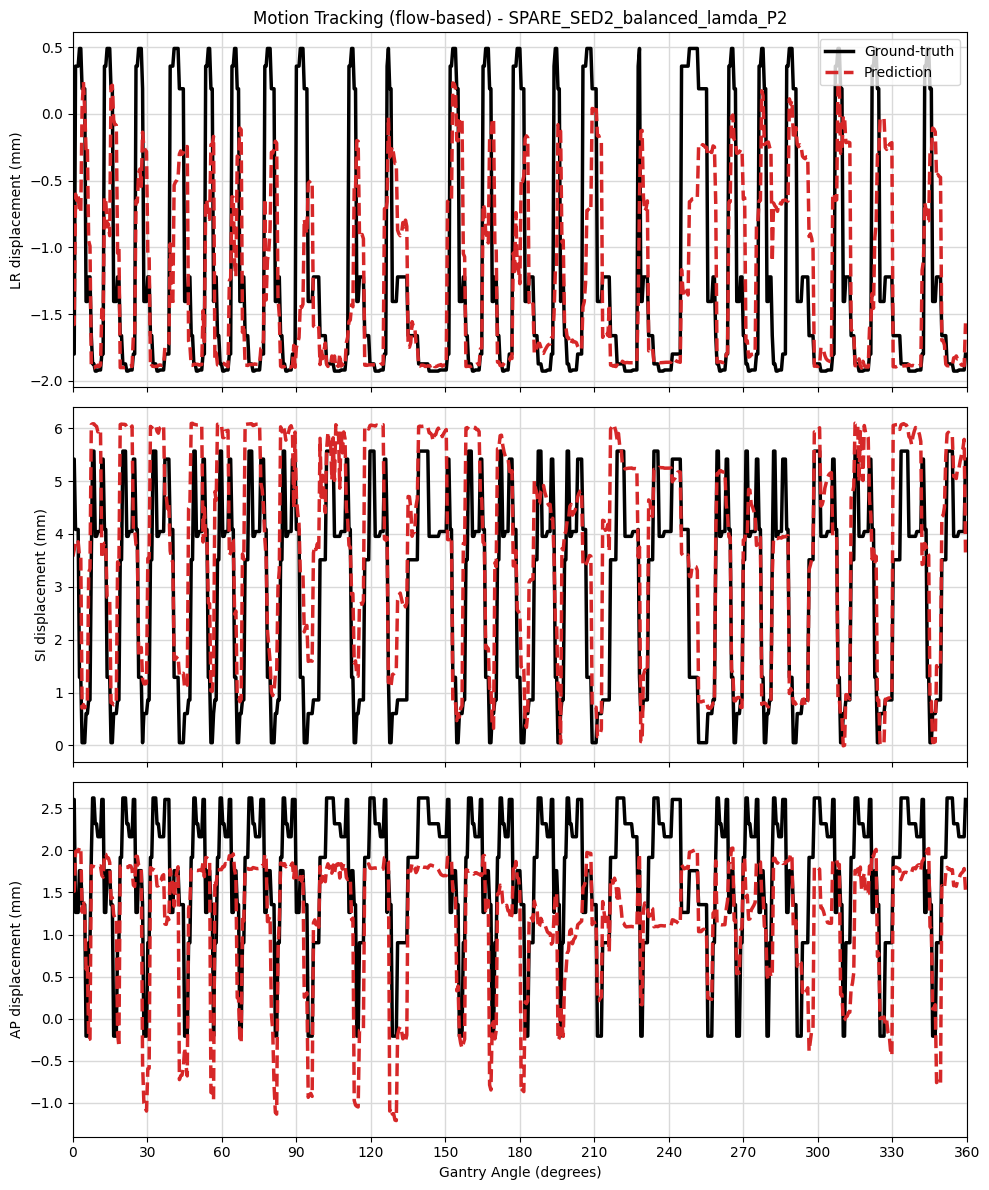

In [46]:

# -------------------------
# PLOTTING SETUP
# -------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

def sort_by_angle(trace, angles):
    trace = np.asarray(trace, dtype=float)
    angles = np.asarray(angles, dtype=float)
    order = np.argsort(angles)
    return angles[order], trace[order]

sorted_angles, tar_lr_plot  = sort_by_angle(tar_lr,  test_angles)
_,            tar_si_plot  = sort_by_angle(tar_si,  test_angles)
_,            tar_ap_plot  = sort_by_angle(tar_ap,  test_angles)

_,            pred_lr_plot = sort_by_angle(pred_lr, test_angles)
_,            pred_si_plot = sort_by_angle(pred_si, test_angles)
_,            pred_ap_plot = sort_by_angle(pred_ap, test_angles)

# -------------------------
# CREATE FIGURE
# -------------------------
f, axes = plt.subplots(
    3, 1,
    figsize=(10, 12),
    sharex=True,
    facecolor="white"
)

labels = [
    "LR displacement (mm)",
    "SI displacement (mm)",
    "AP displacement (mm)"
]

tar_data  = [tar_lr_plot,  tar_si_plot,  tar_ap_plot]
pred_data = [pred_lr_plot, pred_si_plot, pred_ap_plot]

for idx, ax in enumerate(axes):
    ax.set_facecolor("white")

    ax.plot(
        sorted_angles,
        tar_data[idx],
        color="black",
        linewidth=2.5,
        label="Ground-truth"
    )

    ax.plot(
        sorted_angles,
        pred_data[idx],
        linestyle="--",
        color="tab:red",
        linewidth=2.5,
        label="Prediction"
    )

    ax.set_ylabel(labels[idx])
    ax.set_xlim([0, 360])
    ax.set_xticks(np.arange(0, 361, 30))
    ax.grid(True, color="0.85", linewidth=1)

    if idx == 0:
        ax.set_title(f"Motion Tracking (flow-based) - {expt_file}")
        ax.legend(loc="upper right", frameon=True)

axes[-1].set_xlabel("Gantry Angle (degrees)")

f.tight_layout()

# -------------------------
# SAVE FIGURE
# -------------------------
out_path = os.path.join(out_dir, f"{expt_file}_trace.png")
plt.savefig(
    out_path,
    dpi=200,
    facecolor="white",
    edgecolor="white"
)

plt.show()
